In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [3]:
from package_files.benefits_defns import *

In [4]:
path_all = '../data/us_10m_nointernship_ai_skills_benefits.parquet.gzip'

In [5]:
usdf = pd.read_parquet(path_all)

In [8]:
duration_dfs = []
for benefit in benefits4:
    df_duration = usdf.groupby(['AI ROLE',benefit]).agg({'DURATION_CALC':'median'}).reset_index()
    display(df_duration)
    duration_dfs.append(df_duration)

,AI ROLE,EDU_ASSISTANCE,DURATION_CALC
0,False,False,61.0
1,False,True,61.0
2,True,False,61.0
3,True,True,61.0


,AI ROLE,PAID_LEAVE,DURATION_CALC
0,False,False,61.0
1,False,True,61.0
2,True,False,61.0
3,True,True,61.0


,AI ROLE,HEALTH_WELLBEING,DURATION_CALC
0,False,False,61.0
1,False,True,61.0
2,True,False,61.0
3,True,True,61.0


,AI ROLE,PARENTAL_LEAVE,DURATION_CALC
0,False,False,61.0
1,False,True,61.0
2,True,False,61.0
3,True,True,61.0


,AI ROLE,CULTURE,DURATION_CALC
0,False,False,61.0
1,False,True,61.0
2,True,False,61.0
3,True,True,61.0


,AI ROLE,wfh_wham,DURATION_CALC
0,False,0.0,61.0
1,False,1.0,61.0
2,True,0.0,61.0
3,True,1.0,61.0


In [9]:
duration_dfs = []
for benefit in benefits4:
    df_duration = usdf.groupby(['AI ROLE',benefit]).agg({'DURATION_CALC':'mean'}).reset_index()
    display(df_duration)
    duration_dfs.append(df_duration)

,AI ROLE,EDU_ASSISTANCE,DURATION_CALC
0,False,False,59.311959
1,False,True,60.493005
2,True,False,56.937782
3,True,True,57.809169


,AI ROLE,PAID_LEAVE,DURATION_CALC
0,False,False,59.305745
1,False,True,59.694272
2,True,False,57.165929
3,True,True,55.995951


,AI ROLE,HEALTH_WELLBEING,DURATION_CALC
0,False,False,59.356166
1,False,True,60.345132
2,True,False,56.994294
3,True,True,56.822010


,AI ROLE,PARENTAL_LEAVE,DURATION_CALC
0,False,False,59.428018
1,False,True,58.230010
2,True,False,57.079077
3,True,True,55.407394


,AI ROLE,CULTURE,DURATION_CALC
0,False,False,59.421993
1,False,True,59.105173
2,True,False,56.824112
3,True,True,57.654086


,AI ROLE,wfh_wham,DURATION_CALC
0,False,0.0,59.257698
1,False,1.0,54.390959
2,True,0.0,57.180165
3,True,1.0,52.557469


In [7]:
df_duration

,AI ROLE,wfh_wham,DURATION_CALC
0,False,0.0,61.0
1,False,1.0,61.0
2,True,0.0,61.0
3,True,1.0,61.0


KeyboardInterrupt: 

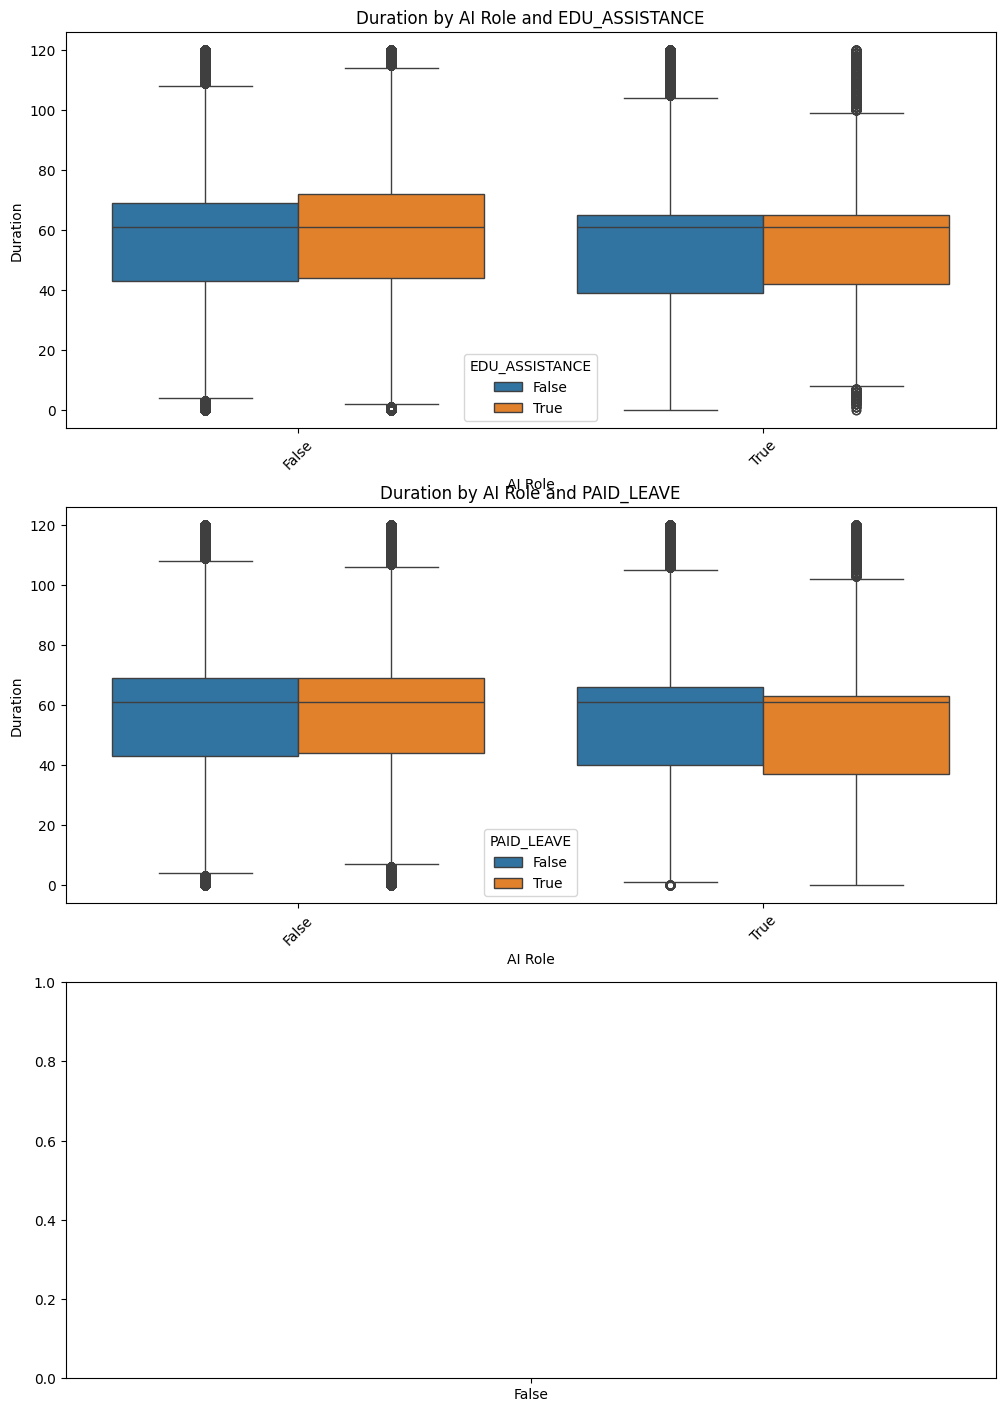

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust the figure size for readability of the plots
plt.figure(figsize=(12, 6 * len(benefits4)))

for i, benefit in enumerate(benefits4, 1):
    plt.subplot(len(benefits4), 1, i)  # Set a subplot for each benefit
    sns.boxplot(x='AI ROLE', y='DURATION_CALC', hue=benefit, data=usdf)
    plt.title(f'Duration by AI Role and {benefit}')
    plt.xlabel('AI Role')
    plt.ylabel('Duration')
    plt.legend(title=benefit)
    plt.xticks(rotation=45)  # Rotate x-axis labels for readability

plt.tight_layout()
plt.show()


In [ ]:
plot_data = usdf.melt(id_vars=['AI ROLE', 'DURATION'], value_vars=benefits4, var_name='Benefit', value_name='Has_Benefit')

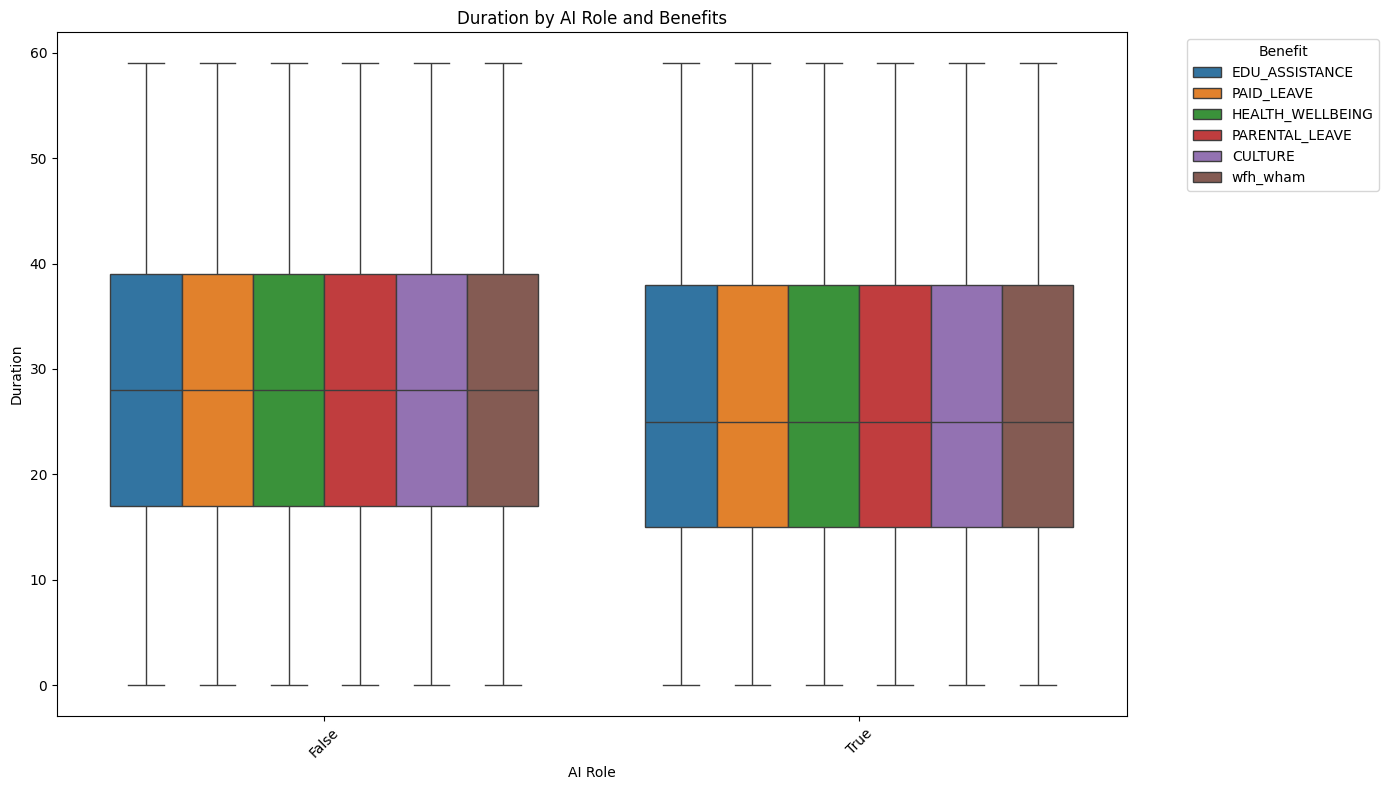

In [11]:

# Create a single box plot grouped by AI ROLE and each benefit
plt.figure(figsize=(14, 8))
sns.boxplot(x='AI ROLE', y='DURATION', hue='Benefit', data=usdf.melt(id_vars=['AI ROLE', 'DURATION'], value_vars=benefits4, var_name='Benefit', value_name='Has_Benefit'))
plt.title('Duration by AI Role and Benefits')
plt.xlabel('AI Role')
plt.ylabel('Duration')
plt.legend(title='Benefit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


In [17]:
df_melted = usdf.melt(id_vars=['AI ROLE', 'DURATION_CALC'], value_vars=benefits4, 
                      var_name='Benefit', value_name='Has_Benefit')

In [18]:
df_melted

,AI ROLE,DURATION_CALC,Benefit,Has_Benefit
0,False,62.0,EDU_ASSISTANCE,0.0
1,False,93.0,EDU_ASSISTANCE,0.0
2,False,61.0,EDU_ASSISTANCE,0.0
3,False,59.0,EDU_ASSISTANCE,0.0
4,False,84.0,EDU_ASSISTANCE,0.0
...,...,...,...,...
69487951,False,119.0,wfh_wham,0.0
69487952,False,66.0,wfh_wham,0.0
69487953,False,61.0,wfh_wham,0.0
69487954,False,67.0,wfh_wham,0.0


/tmp/ipykernel_175936/3052478037.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(x='Benefit', y='DURATION_CALC', hue='AI ROLE', style='Has_Benefit',


AttributeError: Line2D.set() got an unexpected keyword argument 'style'

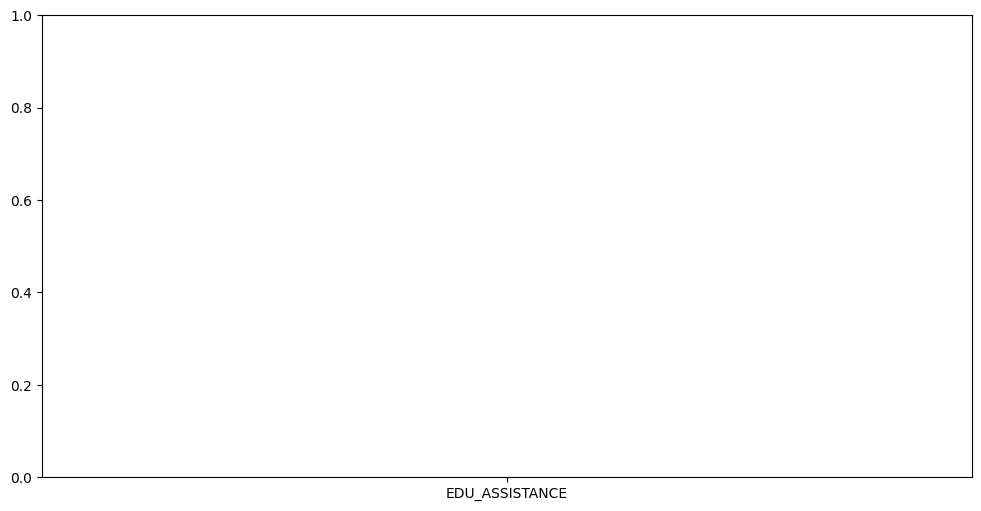

In [20]:
plt.figure(figsize=(12, 6))

sns.pointplot(x='Benefit', y='DURATION_CALC', hue='AI ROLE', style='Has_Benefit', 
              markers=["o", "^"], data=df_melted, dodge=True, errorbar='sd')

plt.title('Duration by AI Role and Benefits')
plt.ylabel('Duration')
plt.xlabel('Benefit')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.legend(title='AI Role / Benefit Presence')
plt.tight_layout()
plt.show()

/tmp/ipykernel_175936/2185566656.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(x='Benefit', y='DURATION_CALC', hue='AI ROLE', col='Has_Benefit',


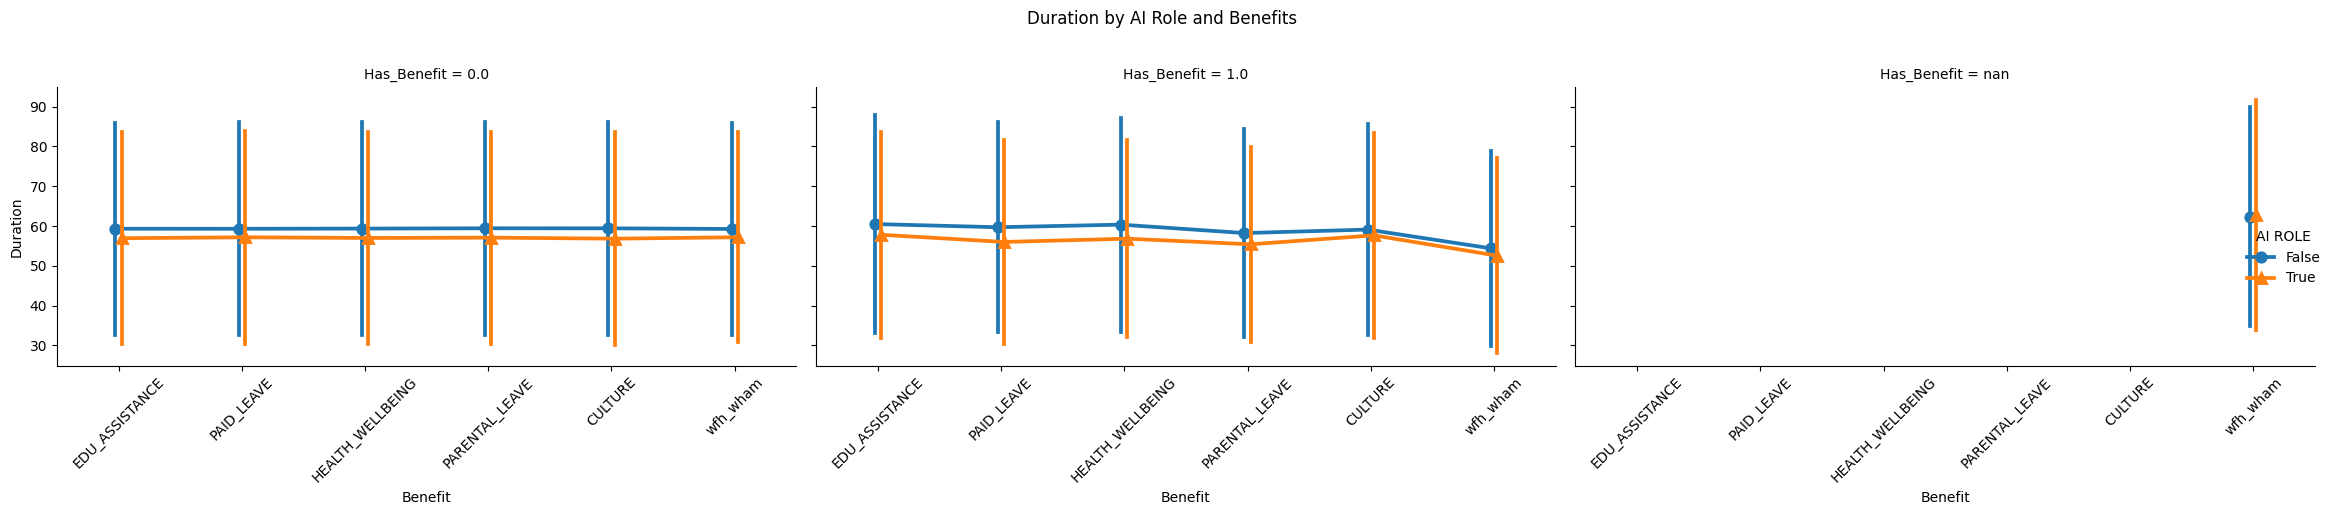

In [22]:
df_melted['Has_Benefit'] = df_melted['Has_Benefit'].astype(str)

# Use catplot with kind='point' to mimic the style from your image
g = sns.catplot(x='Benefit', y='DURATION_CALC', hue='AI ROLE', col='Has_Benefit', 
                kind='point', data=df_melted, dodge=True, ci='sd', 
                markers=["o", "^"], height=5, aspect=1.5)

# Set plot title and adjust labels
g.fig.suptitle('Duration by AI Role and Benefits', y=1.02)
g.set_axis_labels('Benefit', 'Duration')
g.set_xticklabels(rotation=45)

plt.tight_layout()
plt.show()

In [9]:

# Reshape the dataframe to long format for easier plotting
df_melted = usdf.melt(id_vars=['AI ROLE', 'DURATION_CALC'], value_vars=benefits4, 
                      var_name='Benefit', value_name='Has_Benefit')

# Convert Has_Benefit to a string for clear category separation
df_melted['Has_Benefit'] = df_melted['Has_Benefit'].astype(str)
df_melted['AI ROLE'] = df_melted['AI ROLE'].astype(str)

# Create a new column combining AI Role and Has Benefit for better grouping in the plot
df_melted['Role_Benefit'] = df_melted['AI ROLE'] + ' / ' + df_melted['Has_Benefit']




In [10]:
df_melted

,AI ROLE,DURATION_CALC,Benefit,Has_Benefit,Role_Benefit
0,False,62.0,EDU_ASSISTANCE,0.0,False / 0.0
1,False,93.0,EDU_ASSISTANCE,0.0,False / 0.0
2,False,61.0,EDU_ASSISTANCE,0.0,False / 0.0
3,False,59.0,EDU_ASSISTANCE,0.0,False / 0.0
4,False,84.0,EDU_ASSISTANCE,0.0,False / 0.0
...,...,...,...,...,...
69487951,False,119.0,wfh_wham,0.0,False / 0.0
69487952,False,66.0,wfh_wham,0.0,False / 0.0
69487953,False,61.0,wfh_wham,0.0,False / 0.0
69487954,False,67.0,wfh_wham,0.0,False / 0.0


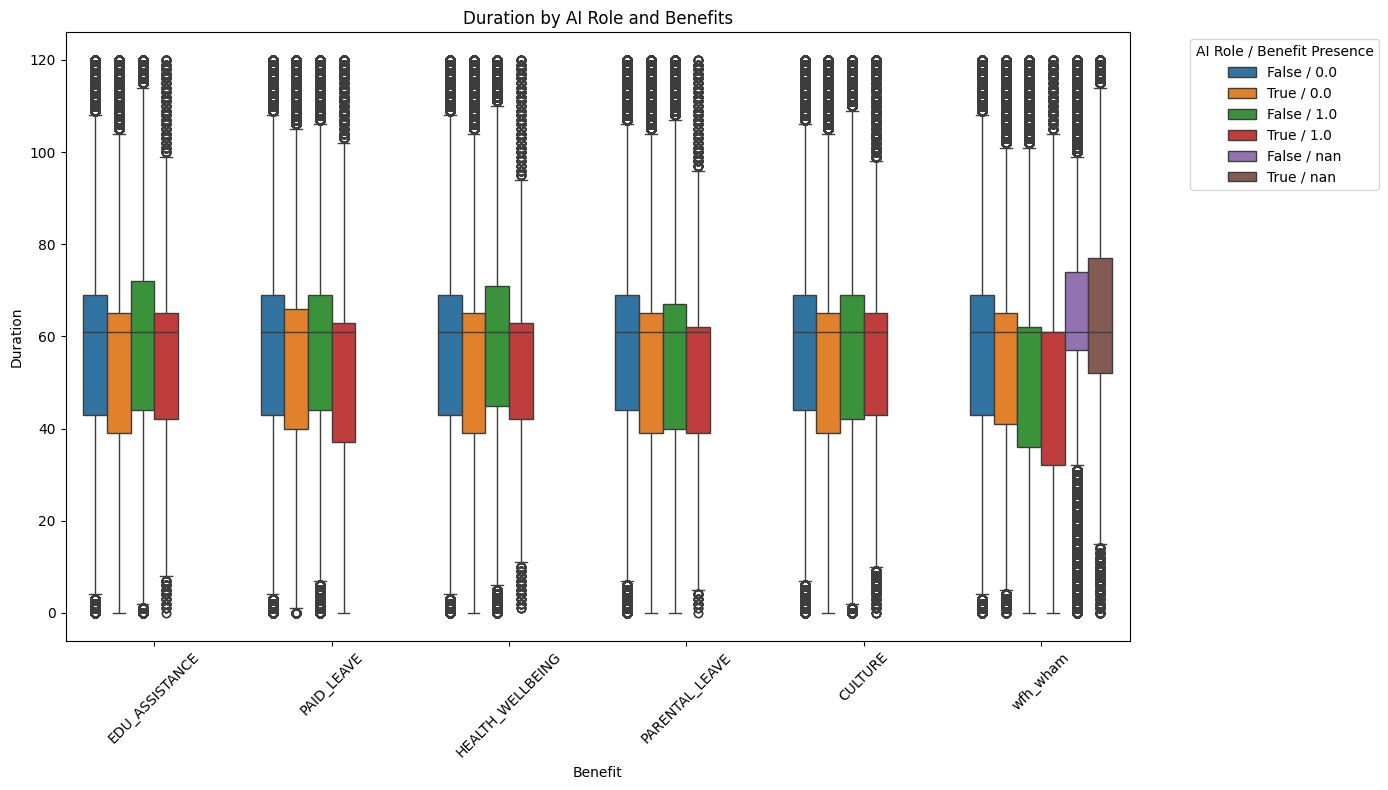

In [12]:
# Plotting
plt.figure(figsize=(14, 8))
sns.boxplot(x='Benefit', y='DURATION_CALC', hue='Role_Benefit', data=df_melted)

plt.title('Duration by AI Role and Benefits')
plt.ylabel('Duration')
plt.xlabel('Benefit')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.legend(title='AI Role / Benefit Presence', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [10]:
benefit_dfs = []
for benefit in benefits4:
    # Create a subset of the data for this specific benefit
    df_subset = usdf[['AI ROLE', 'DURATION_CALC', benefit]].copy()
    df_subset.dropna(subset=[benefit], inplace=True)
    # replace 0s and 1s with False and True in the benefit column
    df_subset[benefit] = df_subset[benefit].replace({0: 'False', 1: 'True'})

    # Rename the benefit column to 'Has_Benefit' for consistency
    df_subset.rename(columns={benefit: 'Has_Benefit'}, inplace=True)

    # Convert Has_Benefit to string for proper category handling
    df_subset['Has_Benefit'] = df_subset['Has_Benefit'].astype(str)
    df_subset['AI ROLE'] = df_subset['AI ROLE'].astype(str)

    # Create a new column combining AI Role and Has Benefit for better grouping in the plot
    df_subset['Role_Benefit'] = df_subset['AI ROLE'] + ' / ' + df_subset['Has_Benefit']
    df_subset['Role_Benefit'] = df_subset['Role_Benefit'].replace({
    'True / True': 'AI Role / Offers Benefit',
    'True / False': 'AI Role / No Benefit',
    'False / True': 'Non-AI Role / Offers Benefit',
    'False / False': 'Non-AI Role / No Benefit'
})
    benefit_dfs.append(df_subset)

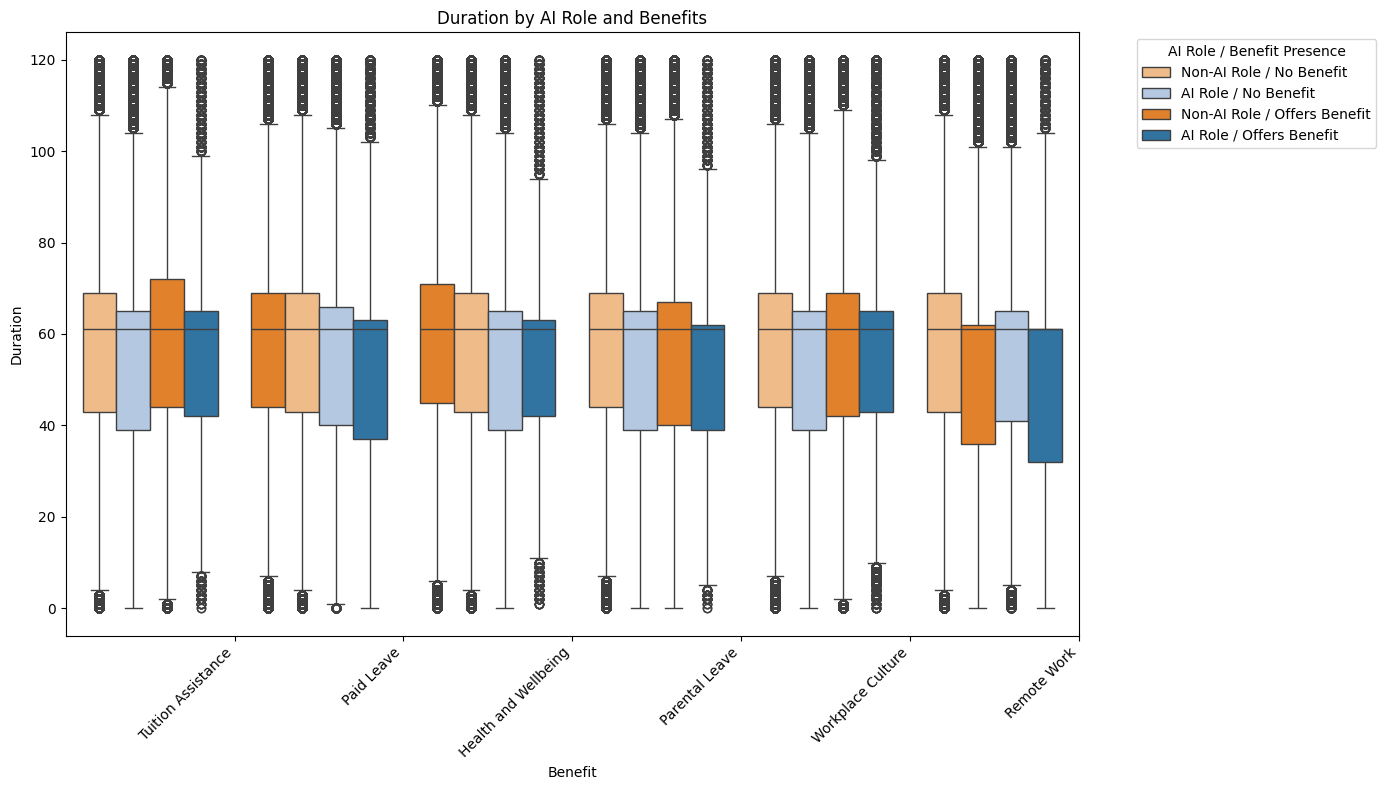

In [10]:
palette = {
    'AI Role / Offers Benefit': '#1f77b4',   # AI Role + Benefit
    'AI Role / No Benefit': '#aec7e8', # AI Role + No Benefit
    'Non-AI Role / Offers Benefit': '#ff7f0e',# Non-AI Role + Benefit
    'Non-AI Role / No Benefit': '#ffbb78' # Non-AI Role + No Benefit
}
# Create a figure for plotting
plt.figure(figsize=(14, 8))
hue_order = ['AI Role / Offers Benefit', 'AI Role / No Benefit', 'Non-AI Role / Offers Benefit', 'Non-AI Role / No Benefit']

for benefit, df_subset in zip(benefits4, benefit_dfs):
    # Plot the boxplot for the current benefit
    sns.boxplot(x=[benefit] * len(df_subset), y='DURATION_CALC', hue='Role_Benefit', data=df_subset, dodge=True, palette=palette)

# Set plot labels and title
plt.title('Duration by AI Role and Benefits')
plt.ylabel('Duration')
plt.xlabel('Benefit')
plt.xticks(ticks=np.arange(len(benefits4))+0.5, labels = benefits4_labels, rotation = 45, ha = 'right')  # Rotate x-axis labels for readability
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles[:4], labels=labels[:4], title='AI Role / Benefit Presence', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


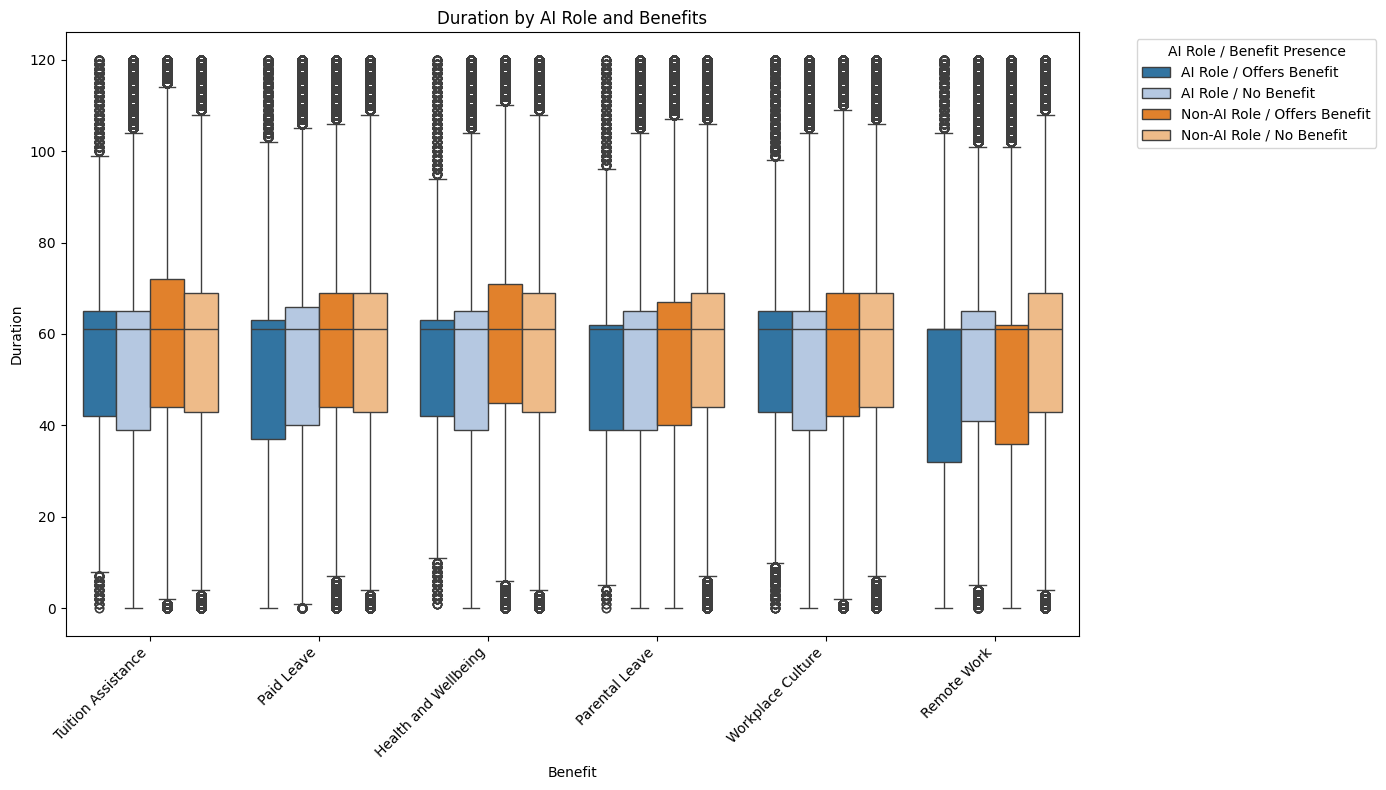

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Adjust your color palette for the updated Role_Benefit labels
palette = {
    'AI Role / Offers Benefit': '#1f77b4',   # AI Role + Benefit
    'AI Role / No Benefit': '#aec7e8',       # AI Role + No Benefit
    'Non-AI Role / Offers Benefit': '#ff7f0e', # Non-AI Role + Benefit
    'Non-AI Role / No Benefit': '#ffbb78'    # Non-AI Role + No Benefit
}

# Assuming benefit_dfs is a list of separate DataFrames, first combine them into a single DataFrame
# Add a new column 'Benefit' to indicate each benefit in the merged DataFrame
combined_df = pd.concat(
    [df.assign(Benefit=benefit) for benefit, df in zip(benefits4, benefit_dfs)],
    ignore_index=True
)

# Map the Role_Benefit column to the more descriptive labels in the combined DataFrame
combined_df['Role_Benefit'] = combined_df['Role_Benefit'].replace({
    'True / True': 'AI Role / Offers Benefit',
    'True / False': 'AI Role / No Benefit',
    'False / True': 'Non-AI Role / Offers Benefit',
    'False / False': 'Non-AI Role / No Benefit'
})

# Create a figure for plotting
plt.figure(figsize=(14, 8))
hue_order = ['AI Role / Offers Benefit', 'AI Role / No Benefit', 'Non-AI Role / Offers Benefit', 'Non-AI Role / No Benefit']

# Plot all benefits in one go
sns.boxplot(x='Benefit', y='DURATION_CALC', hue='Role_Benefit', data=combined_df, dodge=True, palette=palette, hue_order = hue_order)

# Set plot labels and title
plt.title('Duration by AI Role and Benefits')
plt.ylabel('Duration')
plt.xlabel('Benefit')

# Adjust x-tick labels for readability, rotating as needed
plt.xticks(ticks=np.arange(len(benefits4)), labels=benefits4_labels, rotation=45, ha='right')

# Limit the legend to the four desired labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles[:4], labels=labels[:4], title='AI Role / Benefit Presence', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


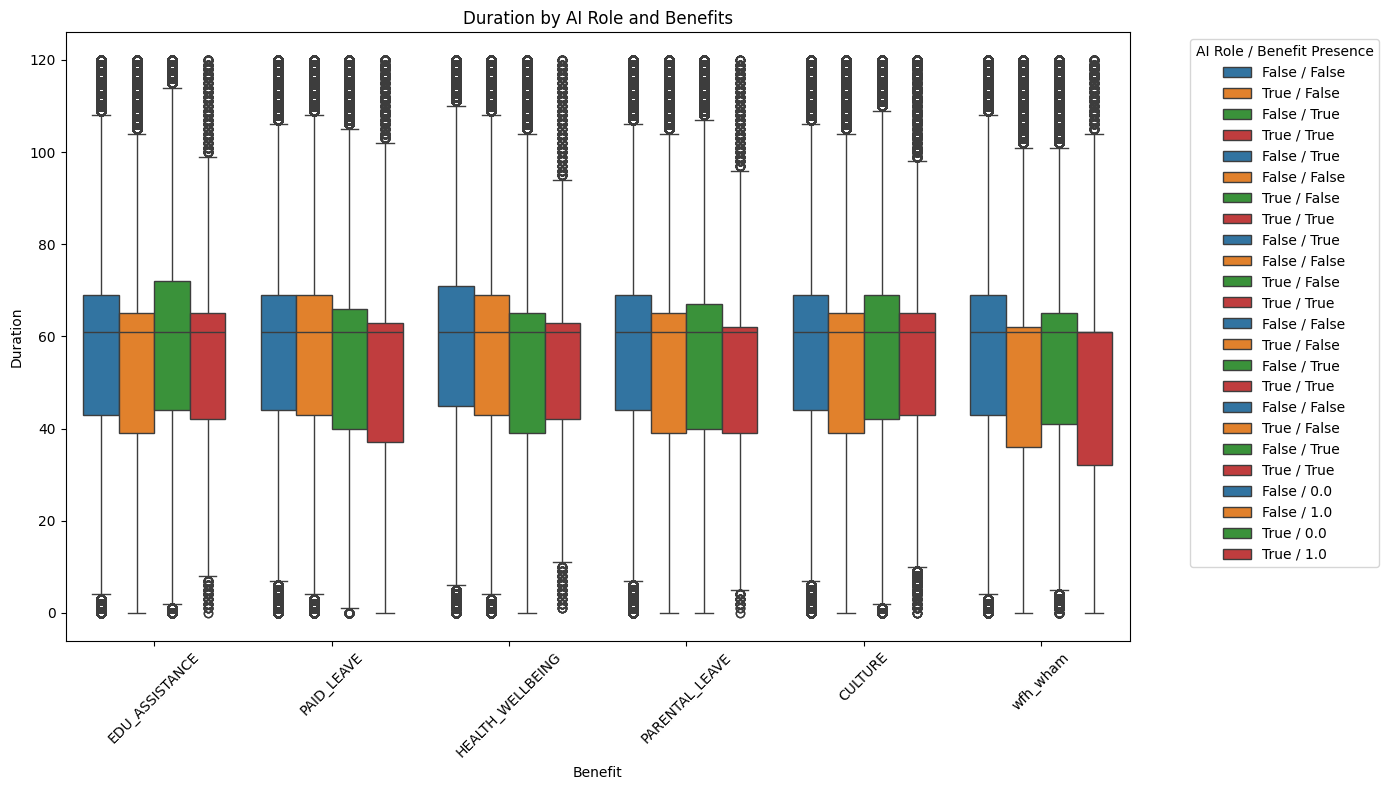

In [14]:
palette = {
    'AI Role / Offers Benefit': '#1f77b4',   # AI Role + Benefit
    'AI Role / No Benefit': '#aec7e8', # AI Role + No Benefit
    'Non-AI Role / Offers Benefit': '#ff7f0e',# Non-AI Role + Benefit
    'Non-AI Role / No Benefit': '#ffbb78' # Non-AI Role + No Benefit
}
# Create a figure for plotting
plt.figure(figsize=(14, 8))

# Loop through each benefit and create a plot
for benefit in benefits4:
    # Create a subset of the data for this specific benefit
    df_subset = usdf[['AI ROLE', 'DURATION_CALC', benefit]].copy()
    df_subset.dropna(subset=[benefit], inplace=True)
    # replace 0s and 1s with False and True in the benefit column
    df_subset[benefit] = df_subset[benefit].replace({0: 'False', 1: 'True'})

    # Rename the benefit column to 'Has_Benefit' for consistency
    df_subset.rename(columns={benefit: 'Has_Benefit'}, inplace=True)

    # Convert Has_Benefit to string for proper category handling
    df_subset['Has_Benefit'] = df_subset['Has_Benefit'].astype(str)
    df_subset['AI ROLE'] = df_subset['AI ROLE'].astype(str)

    # Create a new column combining AI Role and Has Benefit for better grouping in the plot
    df_subset['Role_Benefit'] = df_subset['AI ROLE'] + ' / ' + df_subset['Has_Benefit']
    df_subset['Role_Benefit'] = df_subset['Role_Benefit'].replace({
    'True / True': 'AI Role / Offers Benefit',
    'True / False': 'AI Role / No Benefit',
    'False / True': 'Non-AI Role / Offers Benefit',
    'False / False': 'Non-AI Role / No Benefit'
})
    
    # Plot the boxplot for the current benefit
    sns.boxplot(x=[benefit] * len(df_subset), y='DURATION_CALC', hue='Role_Benefit', data=df_subset, dodge=True, palette=palette)

# Set plot labels and title
plt.title('Duration by AI Role and Benefits')
plt.ylabel('Duration')
plt.xlabel('Benefit')
plt.xticks(ticks = )  # Rotate x-axis labels for readability
plt.legend(title='AI Role / Benefit Presence', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [1]:
df_subset

NameError: name 'df_subset' is not defined

In [19]:
benefit_dfs = []
for benefit in benefits4:
    # Create a subset of the data for this specific benefit
    df_subset = usdf[['AI ROLE', 'DURATION_CALC', benefit]].copy()
    df_subset.dropna(subset=[benefit], inplace=True)
    # replace 0s and 1s with False and True in the benefit column
    df_subset[benefit] = df_subset[benefit].replace({0: 'False', 1: 'True'})

    # Rename the benefit column to 'Has_Benefit' for consistency
    df_subset.rename(columns={benefit: 'Has_Benefit'}, inplace=True)

    # Convert Has_Benefit to string for proper category handling
    df_subset['Has_Benefit'] = df_subset['Has_Benefit'].astype(str)
    df_subset['AI ROLE'] = df_subset['AI ROLE'].astype(str)

    # Create a new column combining AI Role and Has Benefit for better grouping in the plot
    df_subset['Role_Benefit'] = df_subset['AI ROLE'] + ' / ' + df_subset['Has_Benefit']
    df_subset['Role_Benefit'] = df_subset['Role_Benefit'].replace({
    'True / True': 'AI Role / Offers Benefit',
    'True / False': 'AI Role / No Benefit',
    'False / True': 'Non-AI Role / Offers Benefit',
    'False / False': 'Non-AI Role / No Benefit'
})
    
    benefit_dfs.append(df_subset)


In [20]:
df_subset

,AI ROLE,DURATION_CALC,Has_Benefit,Role_Benefit
0,False,62.0,False,Non-AI Role / No Benefit
1,False,93.0,False,Non-AI Role / No Benefit
2,False,61.0,False,Non-AI Role / No Benefit
3,False,59.0,False,Non-AI Role / No Benefit
4,False,84.0,False,Non-AI Role / No Benefit
...,...,...,...,...
11581321,False,119.0,False,Non-AI Role / No Benefit
11581322,False,66.0,False,Non-AI Role / No Benefit
11581323,False,61.0,False,Non-AI Role / No Benefit
11581324,False,67.0,False,Non-AI Role / No Benefit


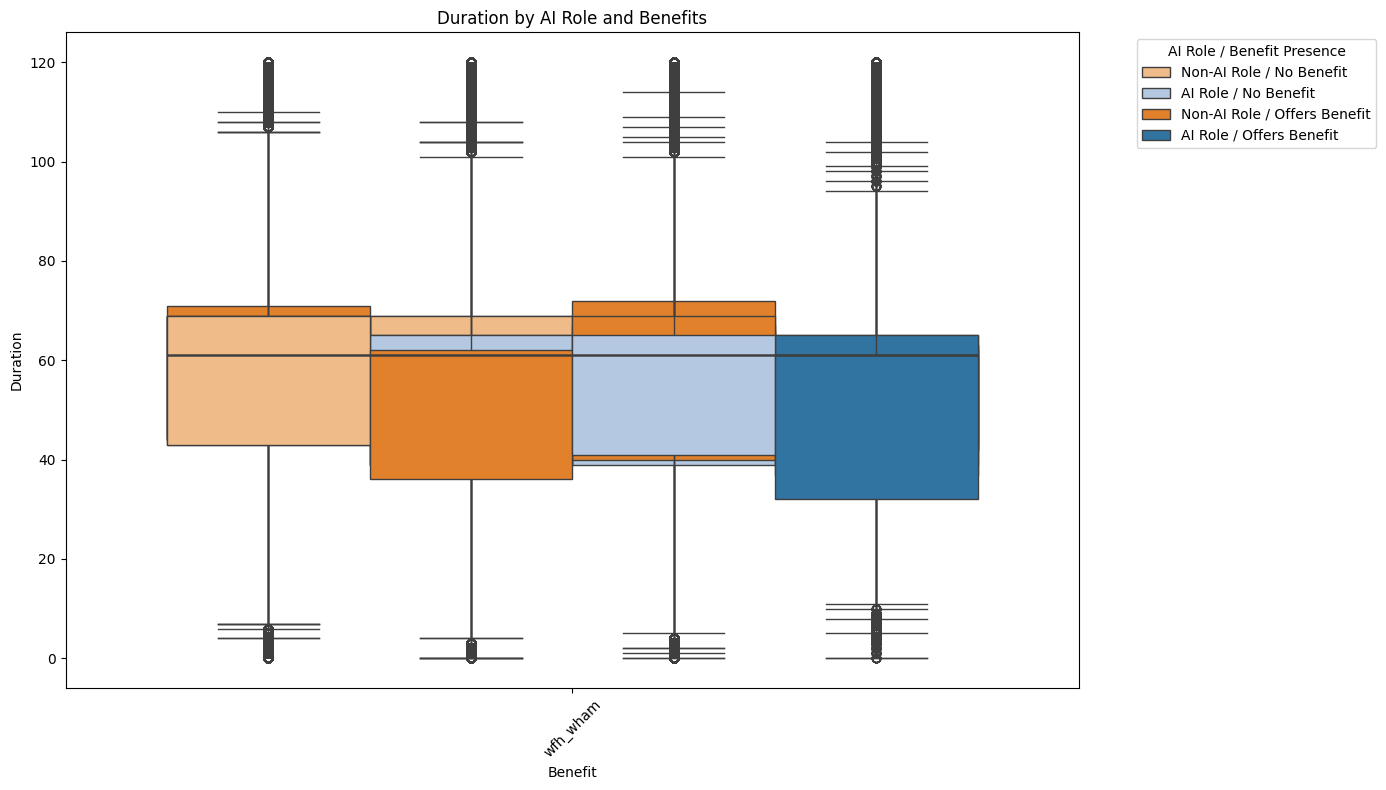

In [22]:
palette = {
    'AI Role / Offers Benefit': '#1f77b4',   # AI Role + Benefit
    'AI Role / No Benefit': '#aec7e8', # AI Role + No Benefit
    'Non-AI Role / Offers Benefit': '#ff7f0e',# Non-AI Role + Benefit
    'Non-AI Role / No Benefit': '#ffbb78' # Non-AI Role + No Benefit
}
# Create a figure for plotting
plt.figure(figsize=(14, 8))

# Loop through each benefit and create a plot
for df_subset in benefit_dfs:
    # Plot the boxplot for the current benefit
    print("loop")
    sns.boxplot(x=[benefit] * len(df_subset), y='DURATION_CALC', hue='Role_Benefit', data=df_subset, dodge=True, palette=palette)
# Set plot labels and title
print("plt")
plt.title('Duration by AI Role and Benefits')
plt.ylabel('Duration')
plt.xlabel('Benefit')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability

# Adjust the legend to only show 4 categories
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles[:4], labels=labels[:4], title='AI Role / Benefit Presence', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()